In [55]:
# Import required modules and libraries
import pandas as pd
import numpy as np
import re
import ast
from string import punctuation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pymorphy3
import stanza
from langdetect import detect, DetectorFactory, LangDetectException
from collections import Counter
from wordcloud import WordCloud

# Build a DataFrame with only negative reviews
### This will be used for training a classification model 
### and for identifying universities' key problems

In [2]:
df = pd.read_csv("C:\\Users\\Користувач\\Desktop\\Project\\materials\\data+bert_sentiment.csv")

In [3]:
# Encode star rating: up to 2 — negative, 3 — neutral, 4–5 — positive
def star_to_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['Star_Sentiment_Category'] = df['Review Rating'].apply(star_to_sentiment)

In [4]:
# Create a column indicating whether the sentiment categories match
df['Match'] = df['Star_Sentiment_Category'] == df['Sentiment_Category_BERT']

In [5]:
# Proportion of matches
accuracy = df['Match'].mean()
print(f"Accuracy of agreement between star rating and BERT sentiment: {accuracy:.2%}")

Accuracy of agreement between star rating and BERT sentiment: 73.31%


In [6]:
# Filter the DataFrame based on conditions
filtered_df = df[
    (df["Sentiment_Category_BERT"] == "negative") &
    (df["Match"] == True)
]

# Select only the required columns
unlabeled_df = filtered_df[["University Name", "Review Text", "Timestamp", "Year"]].reset_index(drop=True)

# Preview the resulting DataFrame
unlabeled_df.head()

,University Name,Review Text,Timestamp,Year
0,University_1,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024
1,University_1,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023
2,University_1,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023
3,University_1,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022
4,University_1,Как бы ректор не заявлял о намерении соответст...,2021-12-15,2021


In [7]:
unlabeled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1866 entries, 0 to 1865
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   University Name  1866 non-null   object
 1   Review Text      1866 non-null   object
 2   Timestamp        1866 non-null   object
 3   Year             1866 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 58.4+ KB


In [8]:
# Convert the 'Timestamp' column to datetime format, setting invalid parsing as NaT
unlabeled_df["Timestamp"] = pd.to_datetime(unlabeled_df["Timestamp"], errors="coerce")
unlabeled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1866 entries, 0 to 1865
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   University Name  1866 non-null   object        
 1   Review Text      1866 non-null   object        
 2   Timestamp        1866 non-null   datetime64[ns]
 3   Year             1866 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 58.4+ KB


In [12]:
labeled_df = pd.read_excel("C:\\Users\\Користувач\\Desktop\\Project\\materials\\df_labeled.xlsx")

In [13]:
# Filter the DataFrame based on conditions
filtered_df = labeled_df[
    (labeled_df["Manual_Category"] == "negative")
]

# Select only the required columns
labeled_df = filtered_df[["University Name", "Review Date", "Review Text", "Timestamp", "Year", "Attitude_Towards_Students", "Campus_conditions", "Corruption",	"Academic_Process_Management",	"Education_Quality"]].reset_index(drop=True)

# Preview the resulting DataFrame
labeled_df .tail()

,University Name,Review Date,Review Text,Timestamp,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
514,University_1,2025-04-16 00:00:00,Ех… І з чого б почати? Формально мінімальна оц...,NaN,NaN,0.0,1.0,0.0,0.0,0.0
515,University_1,2025-02-16 00:00:00,Це найгірший університет у світі. Будь-якому і...,NaN,NaN,0.0,0.0,0.0,1.0,0.0
516,University_1,2024-11-16 00:00:00,"Взятки беруть, топ унік. За 400 долларів можеш...",NaN,NaN,0.0,0.0,1.0,0.0,0.0
517,University_1,2024-09-16 00:00:00,Назва ВНЗ не відповідає дійсності -авіацією ту...,NaN,NaN,0.0,0.0,0.0,0.0,1.0
518,University_1,2023-09-16 00:00:00,Скажу откровенно что уровень преподавания в эт...,NaN,NaN,0.0,0.0,0.0,0.0,1.0


In [14]:
labeled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Name              519 non-null    object 
 1   Review Date                  519 non-null    object 
 2   Review Text                  519 non-null    object 
 3   Timestamp                    443 non-null    object 
 4   Year                         443 non-null    float64
 5   Attitude_Towards_Students    519 non-null    float64
 6   Campus_conditions            519 non-null    float64
 7   Corruption                   519 non-null    float64
 8   Academic_Process_Management  519 non-null    float64
 9   Education_Quality            519 non-null    float64
dtypes: float64(6), object(4)
memory usage: 40.7+ KB


In [15]:
# Mask for dates containing a dot (.)
mask_dot = labeled_df['Review Date'].astype(str).str.contains(r'\.', regex=True, na=False)
# For dates containing dots, convert them to datetime using the format '%d.%m.%Y' and store in 'Timestamp'
labeled_df.loc[mask_dot, 'Timestamp'] = pd.to_datetime(labeled_df.loc[mask_dot, 'Review Date'], format='%d.%m.%Y', errors='coerce')
# Convert review dates in the 'YYYY-MM-DD' format (without dots) to datetime and assign to 'Timestamp'
labeled_df.loc[~mask_dot, 'Timestamp'] = pd.to_datetime(labeled_df.loc[~mask_dot, 'Review Date'], format='%Y-%m-%d', errors='coerce')


In [16]:
# Convert the 'Timestamp' column to datetime format, setting invalid parsing as NaT
labeled_df["Timestamp"] = pd.to_datetime(labeled_df["Timestamp"], errors="coerce")
labeled_df['Year'] =labeled_df.Timestamp.apply(lambda x: x.year)

In [17]:
labeled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   University Name              519 non-null    object        
 1   Review Date                  519 non-null    object        
 2   Review Text                  519 non-null    object        
 3   Timestamp                    519 non-null    datetime64[ns]
 4   Year                         519 non-null    int64         
 5   Attitude_Towards_Students    519 non-null    float64       
 6   Campus_conditions            519 non-null    float64       
 7   Corruption                   519 non-null    float64       
 8   Academic_Process_Management  519 non-null    float64       
 9   Education_Quality            519 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(3)
memory usage: 40.7+ KB


# Cleaning

### Preprocess text:
- convert everything to strings,
- replace NaN, lists, numbers, or unusual formats safely (numbers are kept as strings),
- remove completely empty values,
- lowercase,
- remove unwanted punctuation,
- normalize spaces,
- filter non-letter tokens,
- join back to string

In [18]:
# A format unification step to ensure that the data is at least in string form
def clean_text_column(df, col):
    """
    Convert a column to strings, remove empty entries, and print a summary.

    Handles NaN, numbers, lists, tuples, sets, and string literals of lists.
    Also counts rows containing 'language not supported'.
    """
    # --- Diagnostics before cleaning ---
    print(f"--- Diagnostics before cleaning: {col} ---")
    print(df[col].apply(type).value_counts())

    def to_str_text(x):
        # Replace NaN with empty string
        if pd.isna(x):
            return ""
        # Convert lists, tuples, sets to string
        if isinstance(x, (list, tuple, set)):
            return " ".join(map(str, x)).strip()
        # Convert numbers to string
        if isinstance(x, (int, float, np.integer, np.floating)):
            return str(x)
        s = str(x).strip()
        # If string is a literal list like "['a','b']", parse it
        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (list, tuple, set)):
                    return " ".join(map(str, parsed)).strip()
            except Exception:
                pass
        # Otherwise, keep as string
        return s

    # Apply conversion directly to the same column
    df[col] = df[col].apply(to_str_text)

    # Remove empty strings
    before_count = df.shape[0]
    df = df[df[col].str.strip() != ""].copy()
    after_count = df.shape[0]

    # --- Summary after cleaning ---
    print(f"\n--- After cleaning ---")
    print(df[col].apply(type).value_counts())
    print(f"Removed empty rows: {before_count - after_count} / {before_count} "
          f"({(before_count - after_count)/before_count:.2%})")

    # --- Count 'language not supported' rows ---
    lns_count = (df[col].str.strip().str.lower() == "language not supported").sum()
    print(f"Rows containing 'language not supported': {lns_count}")

    return df

In [19]:
unlabeled_df=clean_text_column(unlabeled_df, "Review Text")
labeled_df=clean_text_column(labeled_df, "Review Text")

--- Diagnostics before cleaning: Review Text ---
Review Text
<class 'str'>    1866
Name: count, dtype: int64

--- After cleaning ---
Review Text
<class 'str'>    1866
Name: count, dtype: int64
Removed empty rows: 0 / 1866 (0.00%)
Rows containing 'language not supported': 0
--- Diagnostics before cleaning: Review Text ---
Review Text
<class 'str'>    519
Name: count, dtype: int64

--- After cleaning ---
Review Text
<class 'str'>    519
Name: count, dtype: int64
Removed empty rows: 0 / 519 (0.00%)
Rows containing 'language not supported': 0


In [20]:
def preprocess_text_for_embeddings(text):
    """
    Preprocess text before generating Sentence Embeddings.
    The function normalizes casing, removes unwanted punctuation,
    and ensures a clean tokenized format suitable for embedding models.
    """
    if not isinstance(text, str):
        return ""

    # Convert text to lowercase
    text = text.lower()

    # Keep numbers as they are, allow letters, digits, spaces, apostrophes, and hyphens
    text = re.sub(r"[^\w\s\-’']", " ", text, flags=re.UNICODE)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Strip leading/trailing hyphens or apostrophes from tokens
    tokens = [w.strip("-'") for w in text.split()]

    return " ".join(tokens)

In [21]:
unlabeled_df["Cleaned_Text"] = unlabeled_df["Review Text"].apply(preprocess_text_for_embeddings) # data cleaning for prediction
labeled_df["Cleaned_Text"] = labeled_df["Review Text"].apply(preprocess_text_for_embeddings) # data cleaning for training the classification model

In [22]:
labeled_df.tail()

,University Name,Review Date,Review Text,Timestamp,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text
514,University_1,2025-04-16 00:00:00,Ех… І з чого б почати? Формально мінімальна оц...,2025-04-16,2025,0.0,1.0,0.0,0.0,0.0,ех і з чого б почати формально мінімальна оцін...
515,University_1,2025-02-16 00:00:00,Це найгірший університет у світі. Будь-якому і...,2025-02-16,2025,0.0,0.0,0.0,1.0,0.0,це найгірший університет у світі будь-якому ін...
516,University_1,2024-11-16 00:00:00,"Взятки беруть, топ унік. За 400 долларів можеш...",2024-11-16,2024,0.0,0.0,1.0,0.0,0.0,взятки беруть топ унік за 400 долларів можеш н...
517,University_1,2024-09-16 00:00:00,Назва ВНЗ не відповідає дійсності -авіацією ту...,2024-09-16,2024,0.0,0.0,0.0,0.0,1.0,назва внз не відповідає дійсності авіацією тут...
518,University_1,2023-09-16 00:00:00,Скажу откровенно что уровень преподавания в эт...,2023-09-16,2023,0.0,0.0,0.0,0.0,1.0,скажу откровенно что уровень преподавания в эт...


# Lemmatization

### Use pymorphy3 for Russian text and Stanza for Ukrainian text lemmatization
### Pymorphy3 is a morphological analyzer specifically designed for the Russian language.
### Stanza is a full NLP pipeline developed by the Stanford NLP team.
### It supports many languages, including Ukrainian.

In [23]:
# Initialize pymorphy3 morphological analyzer for Russian language
morph_ru = pymorphy3.MorphAnalyzer(lang='ru')

# Initialize Stanza pipeline for Ukrainian language 
nlp_uk = stanza.Pipeline('uk', processors='tokenize,mwt,pos,lemma')

2025-10-03 10:24:28 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2025-10-03 10:24:28 INFO: Downloaded file to C:\Users\Користувач\stanza_resources\resources.json
2025-10-03 10:24:29 INFO: Loading these models for language: uk (Ukrainian):
| Processor | Package     |
---------------------------
| tokenize  | iu          |
| mwt       | iu          |
| pos       | iu_charlm   |
| lemma     | iu_nocharlm |

2025-10-03 10:24:29 INFO: Using device: cpu
2025-10-03 10:24:29 INFO: Loading: tokenize
2025-10-03 10:24:33 INFO: Loading: mwt
2025-10-03 10:24:34 INFO: Loading: pos
2025-10-03 10:24:37 INFO: Loading: lemma
2025-10-03 10:24:38 INFO: Done loading processors!


In [24]:
def lemmatize_text(text):
    # Detect the language of the text
    lang = detect(text)
    print(f"Detected language: {lang}")

    # Lemmatization for Russian text
    if lang == 'ru':
        tokens = text.split()
        lemmatized_tokens = ' '.join(morph_ru.parse(word)[0].normal_form for word in tokens)
        return lemmatized_tokens

    # Lemmatization for Ukrainian text
    elif lang == 'uk':
        doc = nlp_uk(text)
        lemmatized_tokens = ' '.join(word.lemma for sent in doc.sentences for word in sent.words)
        return lemmatized_tokens

    else:
        return ["Language not supported"]

In [25]:
unlabeled_df["Lemmatized_Text"] = unlabeled_df["Cleaned_Text"].apply(lemmatize_text)

Detected language: uk
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected l

In [26]:
labeled_df["Lemmatized_Text"] = labeled_df["Cleaned_Text"].apply(lemmatize_text)

Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected l

In [27]:
# Clean text after lemmatization to ensure consistent string format
unlabeled_df=clean_text_column(unlabeled_df, "Lemmatized_Text")
labeled_df=clean_text_column(labeled_df, "Lemmatized_Text")

--- Diagnostics before cleaning: Lemmatized_Text ---
Lemmatized_Text
<class 'str'>     1856
<class 'list'>      10
Name: count, dtype: int64

--- After cleaning ---
Lemmatized_Text
<class 'str'>    1866
Name: count, dtype: int64
Removed empty rows: 0 / 1866 (0.00%)
Rows containing 'language not supported': 10
--- Diagnostics before cleaning: Lemmatized_Text ---
Lemmatized_Text
<class 'str'>    519
Name: count, dtype: int64

--- After cleaning ---
Lemmatized_Text
<class 'str'>    519
Name: count, dtype: int64
Removed empty rows: 0 / 519 (0.00%)
Rows containing 'language not supported': 0


In [28]:
stopwords_ua = [
    "а", "але", "в", "і", "й", "та", "як", "що", "це", "ця", "цей", "цею",
    "тільки", "чи", "чиє", "чия", "хто", "коли", "де", "так", "тут",
    "там", "мій", "твій", "ваш", "наш", "його", "її", "їх", "ви", "ми", "вони",
    "з", "до", "по", "на", "із", "без", "під", "над", "від", "для",
    "якщо", "свої", "я", "який", "тих", "вона", "вони", "їхній", "такий",
    "тоді", "цеї", "ті", "та", "бо", "ось", "ще", "надто", "уже", "б", "моя", "свій",
    "своє", "йому", "нам", "їм", "мені", "просто", "про", "вас", "те",
    "при", "щоб", "тому", "них", "цього", "нас", "вже", "або", "цьому", "нау", "ти", "тебе",
    "мене", "чого", "то", "було", "були", "буде", "була", "яка", "які", "такий", "всі", "є",
    "бути", "навіть", "той", "кожен", "кожний", "перед", "якби", "будь-який", "ех",
    "то", "весь", "щось", "якийсь", "деякий"
]
stopwords_ru = [
    "и", "в", "во", "что", "он", "на", "я", "с", "со", "как", "а", "то",
    "все", "она", "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за",
    "бы", "по", "только", "ее", "мне", "было", "вот", "от", "меня", "еще", "о",
    "из", "ему", "теперь", "когда", "даже", "ну", "вдруг", "ли", "если", "уже",
    "или", "нибудь", "опять", "уж", "вам", "ведь", "там", "потом", "себя", "ничего",
    "ей", "может", "они", "тут", "где", "есть", "надо", "ней", "для", "мы",
    "тебя", "их", "чем", "была", "сам", "чтоб", "без", "будто", "чего", "раз",
    "тоже", "себе", "под", "будет", "ж", "мой", "твой", "моя", "нам", "им", "это",
    "вас", "того", "те", "при", "этом", "кто", "нау", "чтобы", "этого", "свой", "быть", "такой",
    "тот", "каждый", "хотя", "если", "бы", "всё", "этот", "ещё", "который", "то", "что-то",
    "какой-то", "где-то", "как-то", "как бы", "ну", "вот", "весь", "здесь"
]
all_stopwords = set(stopwords_ru + stopwords_ua)

In [29]:
def clean_and_remove_stopwords(text, stopwords):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # заміна чисел на токен
    text = re.sub(r"\d+", "NUM", text)

    # прибираємо пунктуацію, але залишаємо апострофи і дефіси
    text = re.sub(r"[^\w\s\-’']", " ", text, flags=re.UNICODE)

    # прибираємо зайві пробіли
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for w in text.split():
        # Strip leading/trailing hyphens or apostrophes
        w = w.strip("-'")
        
        # Keep the word only if it’s not empty and not a stopword
        if w and w not in stopwords:
            tokens.append(w)

    # Join the cleaned tokens back into a single string
    return " ".join(tokens)

In [30]:
# Remove stopwords after lemmatization

unlabeled_df["Lemmatized_Text"] = unlabeled_df["Lemmatized_Text"].apply(
    lambda x: clean_and_remove_stopwords(x, all_stopwords)
)

labeled_df["Lemmatized_Text"] = labeled_df["Lemmatized_Text"].apply(
    lambda x: clean_and_remove_stopwords(x, all_stopwords)
)

In [31]:
unlabeled_df.head()

,University Name,Review Text,Timestamp,Year,Cleaned_Text,Lemmatized_Text
0,University_1,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024,1 зміст навчання і предмети не відповідають сп...,NUM зміст навчання предмет не відповідати спец...
1,University_1,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023,три года обучения дистанционно хотя в других в...,три год обучение дистанционно другой вуз студе...
2,University_1,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023,працюють лише старі як перед смертю або ті ког...,працювати лише старий смерть немати куди більш...
3,University_1,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022,при поступлении отвратительное отношение кажды...,поступление отвратительный отношение считать д...
4,University_1,Как бы ректор не заявлял о намерении соответст...,2021-12-15,2021,как бы ректор не заявлял о намерении соответст...,ректор не заявлять намерение соответствовать е...


In [32]:
labeled_df.head()

,University Name,Review Date,Review Text,Timestamp,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text,Lemmatized_Text
0,University_1,2021-12-09,По информационному праву Токарева Ксения Серге...,2021-12-09,2021,1.0,0.0,0.0,0.0,0.0,по информационному праву токарева ксения серге...,информационный право токарев ксения сергеевич ...
1,University_1,2021-08-25,Людоньки це *****. Моя дочку поселили в кімнат...,2021-08-25,2021,0.0,1.0,0.0,0.0,0.0,людоньки це моя дочку поселили в кімнату з дів...,людоньки дочка поселити кімната дівчина NUM хл...
2,University_1,2019-06-08,"Шановні вступники, якщо ви хочете зберегти сво...",2019-06-08,2019,1.0,1.0,0.0,0.0,0.0,шановні вступники якщо ви хочете зберегти свої...,шановний вступник хотіти зберегти нерв здоров’...
3,University_1,2019-05-25,Советую ПРОКУРАТУРЕ проверить отдел закупок чт...,2019-05-25,2019,0.0,0.0,1.0,0.0,0.0,советую прокуратуре проверить отдел закупок чт...,советовать прокуратура проверить отдел закупка...
4,University_1,2019-05-19,Не знаю як і хто а я звязав своє життя з НАУ я...,2019-05-19,2019,0.0,0.0,0.0,0.0,1.0,не знаю як і хто а я звязав своє життя з нау я...,не знати звязати життя студент гроші коментар ...


# Remove reviews with extremely high word count

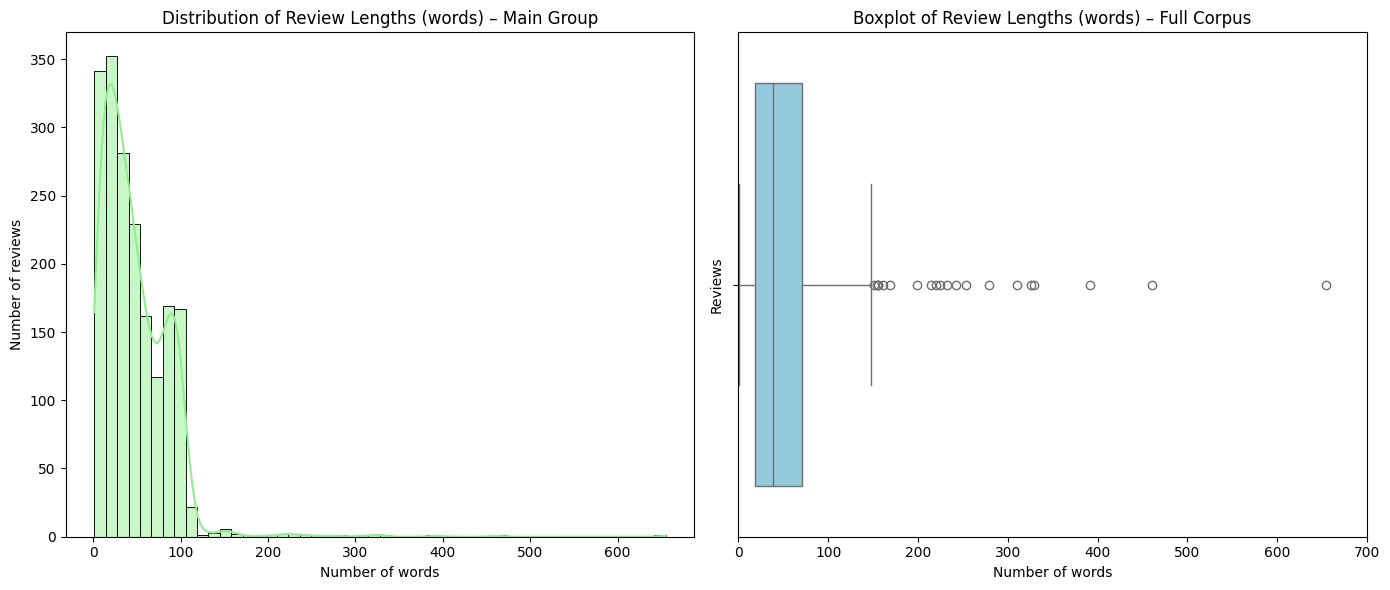

In [33]:
# Define maximum word count threshold (focus on reviews with <= 220 words)
max_words = 700

# Compute word counts directly from text
word_lengths = unlabeled_df["Lemmatized_Text"].str.split().str.len()

# Filter reviews that fall within the main range
main_df = unlabeled_df[word_lengths <= max_words]

plt.figure(figsize=(14,6))

# 1️⃣ Histogram + KDE for the main group of reviews
plt.subplot(1,2,1)
sns.histplot(word_lengths[word_lengths <= max_words], bins=50, kde=True, color="lightgreen")
plt.title("Distribution of Review Lengths (words) – Main Group")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")

# 2️⃣ Boxplot for the full dataset to detect outliers
plt.subplot(1,2,2)
sns.boxplot(x=word_lengths, color="skyblue")
plt.title("Boxplot of Review Lengths (words) – Full Corpus")
plt.xlabel("Number of words")
plt.ylabel("Reviews")
plt.xlim(0, 700)  # adjust to see the long tail

plt.tight_layout()
plt.show()

In [38]:
# Remove reviews where the number of words > 147
unlabeled_df = unlabeled_df[
    unlabeled_df["Lemmatized_Text"].apply(lambda x: len(str(x).split())) <= 147
].copy()

# Check the remaining number of reviews
unlabeled_df.shape[0]

1844

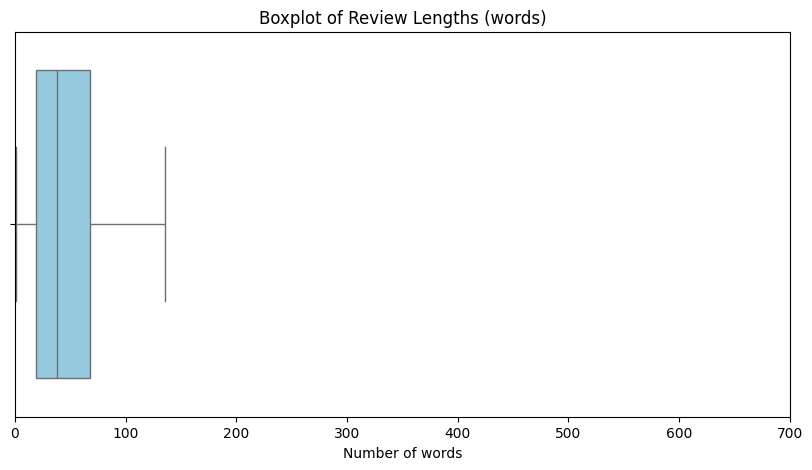

In [39]:
# Boxplot for checking if all outlier reviews (very long texts) were removed

# Compute word counts directly from text
word_lengths = unlabeled_df["Lemmatized_Text"].str.split().str.len()

plt.figure(figsize=(10, 5))
sns.boxplot(x=word_lengths, color="skyblue")
plt.title("Boxplot of Review Lengths (words)")
plt.xlabel("Number of words")
plt.xlim(0, 700)  # adjust to see the long tail

plt.show()

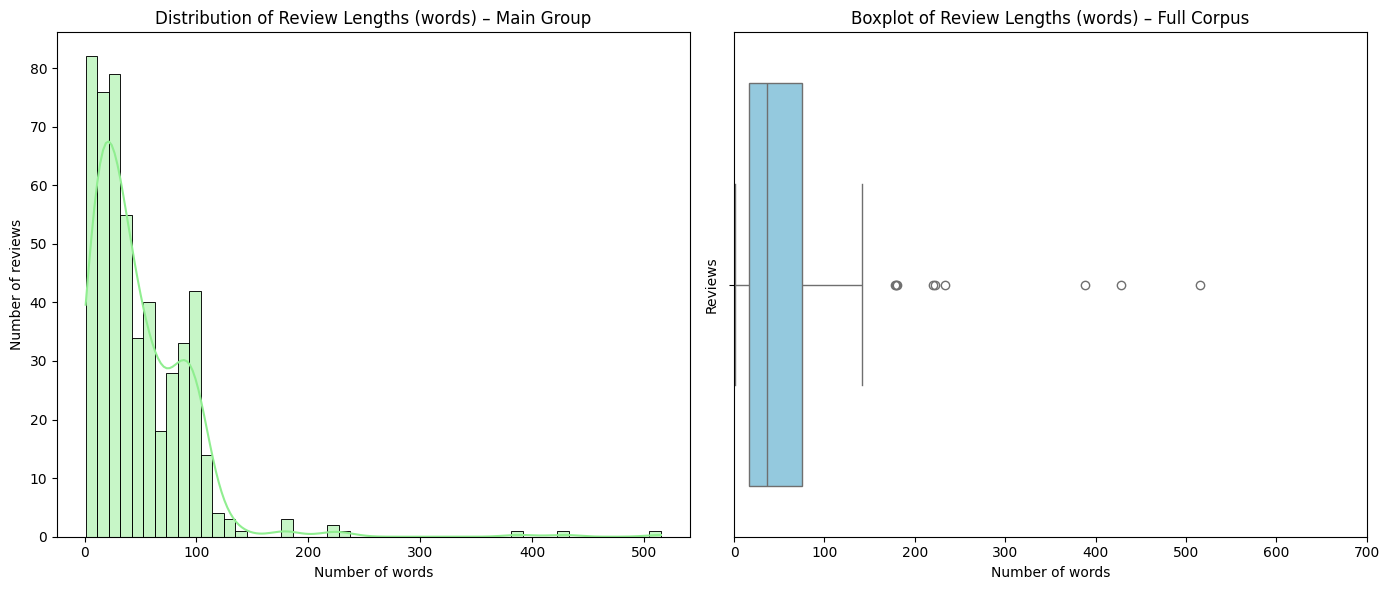

In [40]:
# Define maximum word count threshold (focus on reviews with <= 220 words)
max_words = 700

# Compute word counts directly from text
word_lengths = labeled_df["Lemmatized_Text"].str.split().str.len()

# Filter reviews that fall within the main range
main_df = labeled_df[word_lengths <= max_words]

plt.figure(figsize=(14,6))

# 1️⃣ Histogram + KDE for the main group of reviews
plt.subplot(1,2,1)
sns.histplot(word_lengths[word_lengths <= max_words], bins=50, kde=True, color="lightgreen")
plt.title("Distribution of Review Lengths (words) – Main Group")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")

# 2️⃣ Boxplot for the full dataset to detect outliers
plt.subplot(1,2,2)
sns.boxplot(x=word_lengths, color="skyblue")
plt.title("Boxplot of Review Lengths (words) – Full Corpus")
plt.xlabel("Number of words")
plt.ylabel("Reviews")
plt.xlim(0, 700)  # adjust to see the long tail

plt.tight_layout()
plt.show()

In [41]:
# Remove reviews where the number of words > 164
labeled_df = labeled_df[
    labeled_df["Lemmatized_Text"].apply(lambda x: len(str(x).split())) <= 164
].copy()

# Check the remaining number of reviews
labeled_df.shape[0]

509

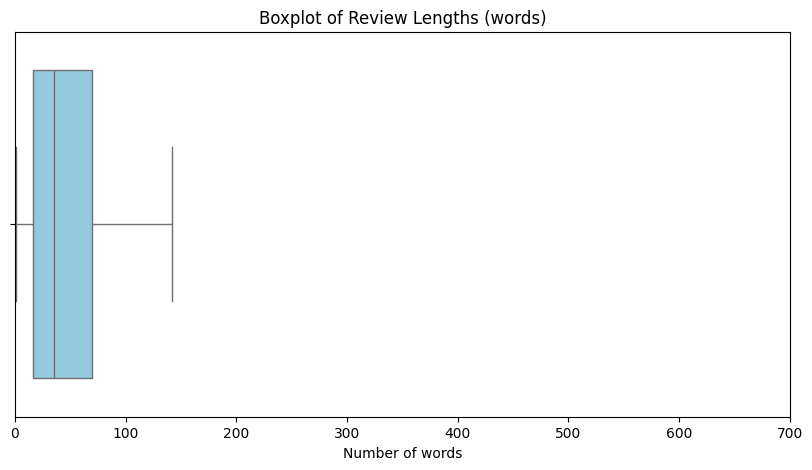

In [42]:
# Boxplot for checking if all outlier reviews (very long texts) were removed

# Compute word counts directly from text
word_lengths = labeled_df["Lemmatized_Text"].str.split().str.len()

plt.figure(figsize=(10, 5))
sns.boxplot(x=word_lengths, color="skyblue")
plt.title("Boxplot of Review Lengths (words)")
plt.xlabel("Number of words")
plt.xlim(0, 700)  # adjust to see the long tail

plt.show()

# Language Detection & Filtering

                 labeled %  unlabeled %
Lemmatized_Text                        
uk               55.206287    47.342733
ru               43.222004    50.596529
unknown           0.982318     1.138829
bg                0.392927     0.216920
mk                0.196464     0.162690
en                0.000000     0.542299


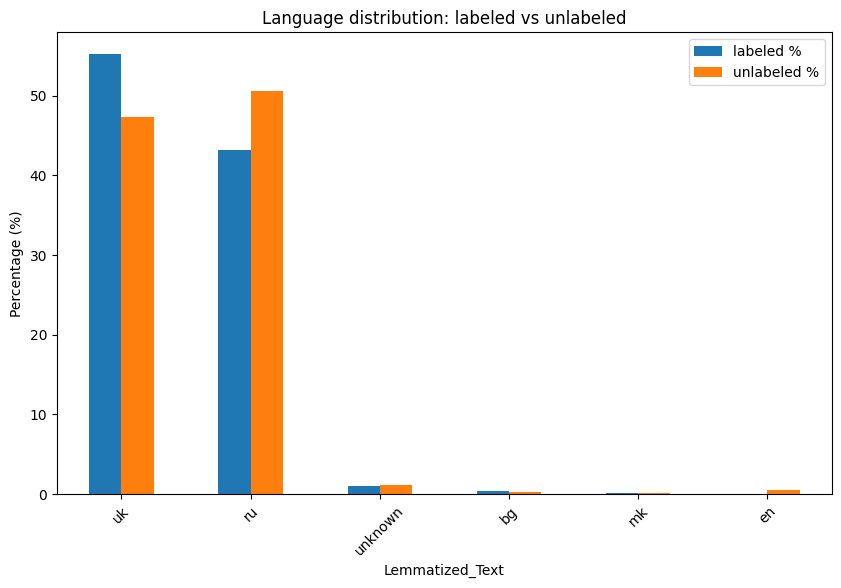

In [43]:
def safe_detect(text):
    """
    Safely detect the language of a text.
    - Converts to string and trims whitespace
    - Returns 'unknown' if text is too short (<3 words) or detection fails
    """
    text = str(text).strip()
    if not text or len(text.split()) < 3:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

# -------------------------
# Compute language counts on the fly
# -------------------------
lang_labeled = labeled_df["Lemmatized_Text"].apply(safe_detect).value_counts(normalize=True) * 100
lang_unlabeled = unlabeled_df["Lemmatized_Text"].apply(safe_detect).value_counts(normalize=True) * 100

# Combine into one table
lang_comparison = pd.concat([lang_labeled, lang_unlabeled], axis=1, keys=["labeled %", "unlabeled %"]).fillna(0)

print(lang_comparison)

# -------------------------
# Visualization
# -------------------------
lang_comparison.plot(kind="bar", figsize=(10, 6))
plt.title("Language distribution: labeled vs unlabeled")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.show()

In [44]:
# to keep only rows where the detected language of the text is Ukrainian or Russian

# Set seed to make language detection results deterministic
DetectorFactory.seed = 0

def filter_uk_ru(df, text_col="Lemmatized_Text"):
    """
    Keep only rows where language is Ukrainian ('uk') or Russian ('ru').
    """
    def is_uk_or_ru(text):
        if not isinstance(text, str) or text.strip() == "":
            return False
        try:
            lang = detect(text)
            return lang in ["uk", "ru"]
        except:
            return False

    # Create mask for rows where language is 'uk' or 'ru'
    mask = df[text_col].apply(is_uk_or_ru)
    df_filtered = df[mask].copy()
    
    # Print statistics about filtering
    print(f"Rows before filtering: {len(df)}")
    print(f"Rows after keeping only uk/ru: {len(df_filtered)}")
    print(f"Removed rows: {len(df) - len(df_filtered)}")
    
    return df_filtered

In [45]:
unlabeled_df = filter_uk_ru(unlabeled_df, text_col="Lemmatized_Text")

Rows before filtering: 1844
Rows after keeping only uk/ru: 1826
Removed rows: 18


In [46]:
# Drop rows where safe_detect returns 'unknown'
def drop_unknown_rows(df, text_col="Lemmatized_Text"):

    mask = df[text_col].apply(lambda x: safe_detect(x) != "unknown")
    return df[mask].copy()

In [47]:
unlabeled_df = drop_unknown_rows(unlabeled_df)

In [48]:
unlabeled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1806 entries, 0 to 1865
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   University Name  1806 non-null   object        
 1   Review Text      1806 non-null   object        
 2   Timestamp        1806 non-null   datetime64[ns]
 3   Year             1806 non-null   int64         
 4   Cleaned_Text     1806 non-null   object        
 5   Lemmatized_Text  1806 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 98.8+ KB


In [49]:
labeled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 509 entries, 0 to 518
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   University Name              509 non-null    object        
 1   Review Date                  509 non-null    object        
 2   Review Text                  509 non-null    object        
 3   Timestamp                    509 non-null    datetime64[ns]
 4   Year                         509 non-null    int64         
 5   Attitude_Towards_Students    509 non-null    float64       
 6   Campus_conditions            509 non-null    float64       
 7   Corruption                   509 non-null    float64       
 8   Academic_Process_Management  509 non-null    float64       
 9   Education_Quality            509 non-null    float64       
 10  Cleaned_Text                 509 non-null    object        
 11  Lemmatized_Text              509 non-null    objec

# Merge datasets and analyze vocabulary (unique words + top words)


In [50]:
# Combine reviews_with_predictions and reviews_labeled into full_dataset
full_df = pd.concat([unlabeled_df, labeled_df], ignore_index=True)

In [51]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2315 entries, 0 to 2314
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   University Name              2315 non-null   object        
 1   Review Text                  2315 non-null   object        
 2   Timestamp                    2315 non-null   datetime64[ns]
 3   Year                         2315 non-null   int64         
 4   Cleaned_Text                 2315 non-null   object        
 5   Lemmatized_Text              2315 non-null   object        
 6   Review Date                  509 non-null    object        
 7   Attitude_Towards_Students    509 non-null    float64       
 8   Campus_conditions            509 non-null    float64       
 9   Corruption                   509 non-null    float64       
 10  Academic_Process_Management  509 non-null    float64       
 11  Education_Quality            509 non-null  

In [52]:
# dropping the original date column
full_df = full_df.drop(columns=["Review Date"])

In [53]:
full_df.head()

,University Name,Review Text,Timestamp,Year,Cleaned_Text,Lemmatized_Text,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
0,University_1,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024,1 зміст навчання і предмети не відповідають сп...,NUM зміст навчання предмет не відповідати спец...,NaN,NaN,NaN,NaN,NaN
1,University_1,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023,три года обучения дистанционно хотя в других в...,три год обучение дистанционно другой вуз студе...,NaN,NaN,NaN,NaN,NaN
2,University_1,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023,працюють лише старі як перед смертю або ті ког...,працювати лише старий смерть немати куди більш...,NaN,NaN,NaN,NaN,NaN
3,University_1,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022,при поступлении отвратительное отношение кажды...,поступление отвратительный отношение считать д...,NaN,NaN,NaN,NaN,NaN
4,University_1,Как бы ректор не заявлял о намерении соответст...,2021-12-15,2021,как бы ректор не заявлял о намерении соответст...,ректор не заявлять намерение соответствовать е...,NaN,NaN,NaN,NaN,NaN


In [54]:
def top_tokens(df, col="Lemmatized_Text", top_k=50):
    """
    Return a DataFrame with top_k tokens and their counts for the given df and column.
    Also prints the number of unique tokens.
    """
    texts = df[col].dropna().astype(str)
    tokens = []
    for t in texts:
        tokens.extend(t.split())
    counts = Counter(tokens)

    # Print number of unique tokens
    print(f"Number of unique tokens: {len(counts)}")

    # Get top-k tokens
    topk = counts.most_common(top_k)
    df_top = pd.DataFrame(topk, columns=["Token", "Count"])
    return df_top

# Top-30 for full_dataset
top_30_full = top_tokens(full_df, col="Lemmatized_Text", top_k=30)

print(top_30_full.to_string(index=False))

Number of unique tokens: 15885
        Token  Count
           не   5525
          NUM   2475
      студент   1150
     викладач    874
          вуз    618
преподаватель    541
    факультет    496
         один    472
          год    457
  університет    456
     навчання    418
          рік    410
      хороший    406
         курс    393
         пара    379
      учиться    377
      предмет    327
       диплом    314
      кафедра    313
         мочь    312
         дуже    312
  университет    304
       знание    302
          нет    293
        очень    290
       хотіти    276
       хотеть    271
        гроші    268
       деньга    264
      человек    264


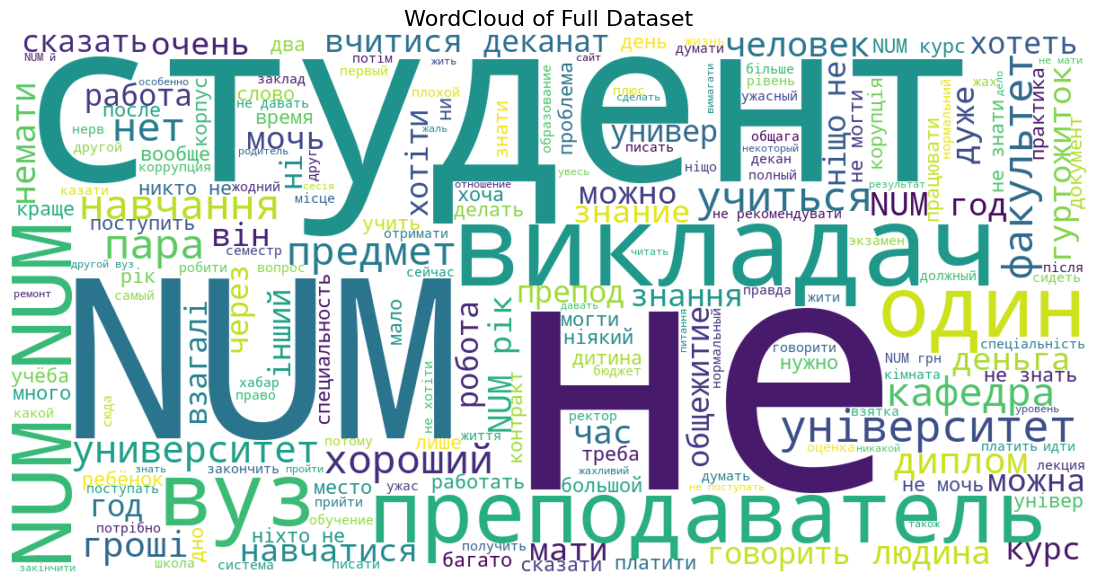

In [56]:
# Combine all lemmatized texts into one string
all_text = " ".join(full_df["Lemmatized_Text"].dropna().astype(str))

# Create a WordCloud object
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",  # can change to "plasma", "inferno", "coolwarm", etc.
    max_words=200
).generate(all_text)

# Visualize the WordCloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Full Dataset", fontsize=16)
plt.show()

In [57]:
unlabeled_df.to_csv("unlabeled_df.csv", index=False, sep=";", encoding="utf-8")
labeled_df.to_csv("labeled_df.csv", index=False, sep=";", encoding="utf-8")
full_df.to_csv("full_df.csv", index=False, sep=";", encoding="utf-8")